In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df=pd.read_csv("Amazon.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200


In [49]:

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


* Date column is an object and it need to convert date for further analysis

In [50]:
# Date is converted into datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

In [51]:
df.set_index('Date', inplace=True)

In [52]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6155.000000,6155.000000,6155.000000,6155.000000,6155.000000,6.155000e+03
mean,520.556302,526.216132,514.277282,520.429832,520.429832,7.329010e+06
std,857.161696,865.821041,847.270905,856.668492,856.668492,7.149521e+06
min,1.406250,1.447917,1.312500,1.395833,1.395833,4.872000e+05
25%,38.750000,39.514999,38.104999,38.821251,38.821251,3.579350e+06
50%,92.669998,94.190002,90.750000,92.639999,92.639999,5.470000e+06
75%,528.949982,535.304993,521.950012,529.450012,529.450012,8.294950e+06
max,3744.000000,3773.080078,3696.790039,3731.409912,3731.409912,1.043292e+08


In [53]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200
...,...,...,...,...,...,...
2021-10-21,3414.250000,3440.280029,3403.000000,3435.010010,3435.010010,1881400
2021-10-22,3421.000000,3429.840088,3331.300049,3335.550049,3335.550049,3133800
2021-10-25,3335.000000,3347.800049,3297.699951,3320.370117,3320.370117,2226000


Total Return: 173322.49%
CAGR: 35.71%
Max Drawdown: -94.40%
Standard Deviation of Returns: 57.89% (Annualized Volatility)


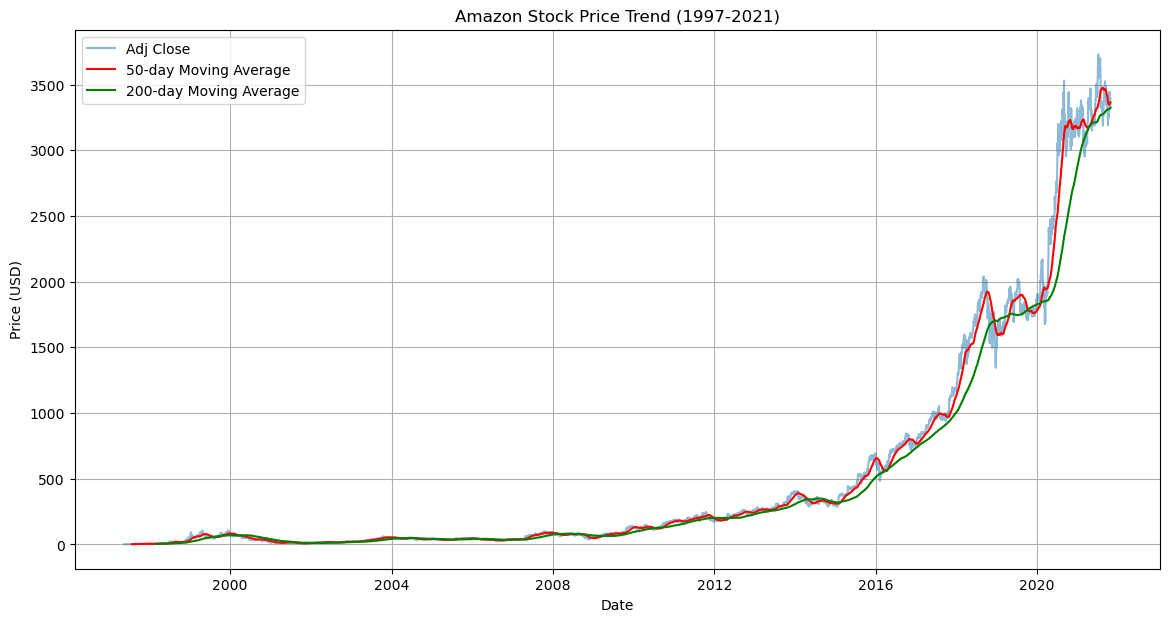

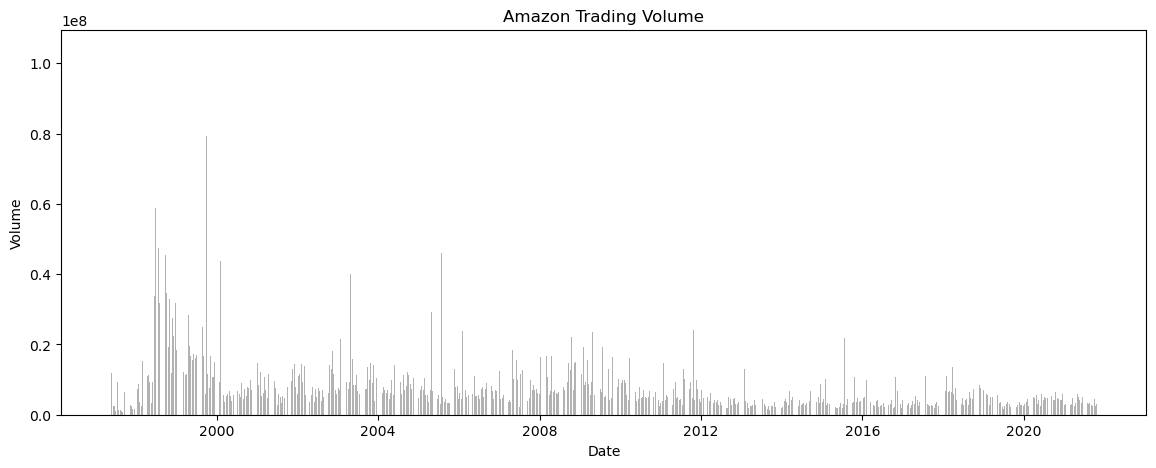

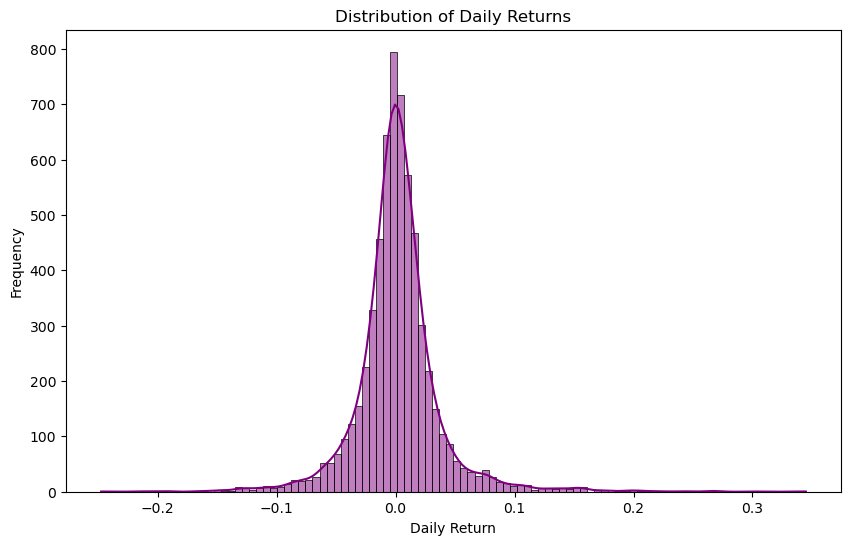

In [55]:
# Calculate Daily Returns
df['Daily Return'] = df['Adj Close'].pct_change()

# Calculate Moving Averages
df['MA50'] = df['Adj Close'].rolling(window=50).mean()
df['MA200'] = df['Adj Close'].rolling(window=200).mean()

# Visualization 1: Stock Price Trend with Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(df['Adj Close'], label='Adj Close', alpha=0.5)
plt.plot(df['MA50'], label='50-day Moving Average', color='red')
plt.plot(df['MA200'], label='200-day Moving Average', color='green')
plt.title('Amazon Stock Price Trend (1997-2021)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('amazon_price_trend.png')

# Visualization 2: Volume Trend
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['Volume'], color='gray', alpha=0.6)
plt.title('Amazon Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.savefig('amazon_volume_trend.png')

# Visualization 3: Daily Returns Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.savefig('amazon_returns_dist.png')

# Yearly Growth
yearly_perf = df['Adj Close'].resample('Y').last().pct_change() * 100
yearly_avg_vol = df['Volume'].resample('Y').mean()

# Key Statistics
total_return = (df['Adj Close'][-1] / df['Adj Close'][0] - 1) * 100
cagr = ((df['Adj Close'][-1] / df['Adj Close'][0]) ** (1 / (len(df)/252)) - 1) * 100
max_drawdown = ((df['Adj Close'] / df['Adj Close'].cummax()) - 1).min() * 100

print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Standard Deviation of Returns: {df['Daily Return'].std() * np.sqrt(252) * 100:.2f}% (Annualized Volatility)")

Recent (Last 5 Years) Total Return: 315.00%
Recent (Last 5 Years) CAGR: 32.93%

Top 5 Best Days (Returns):
Date
2001-11-26    0.344714
2001-04-09    0.335723
2001-11-14    0.301783
2007-04-25    0.269497
2009-10-23    0.267951
Name: Daily Return, dtype: float64

Top 5 Worst Days (Returns):
Date
2001-07-24   -0.247661
2006-07-26   -0.218220
1998-08-31   -0.209090
2001-10-24   -0.200000
2000-06-23   -0.193452
Name: Daily Return, dtype: float64

Monthly Seasonality (Average Daily Return %):
Month
1     0.225744
2    -0.133268
3     0.265997
4     0.474590
5     0.009136
6     0.192854
7     0.184658
8     0.109563
9     0.334000
10    0.184300
11    0.349977
12    0.030307
Name: Daily Return, dtype: float64


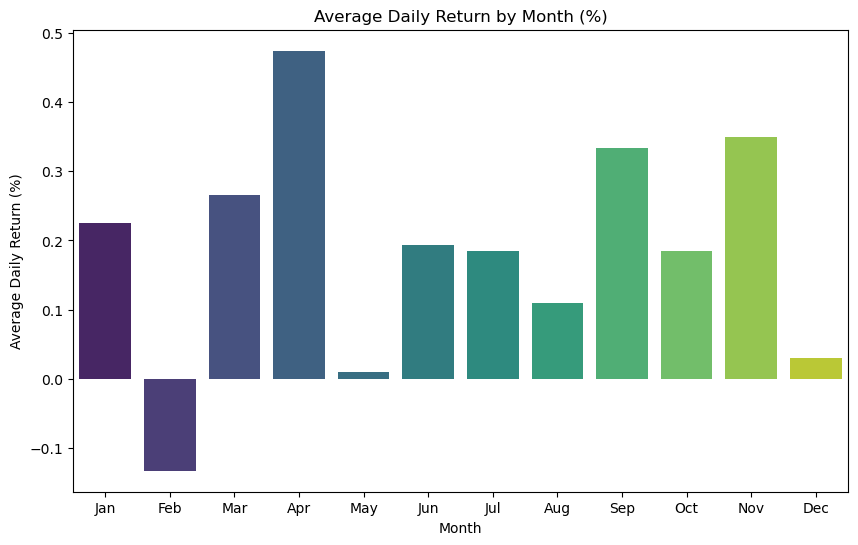

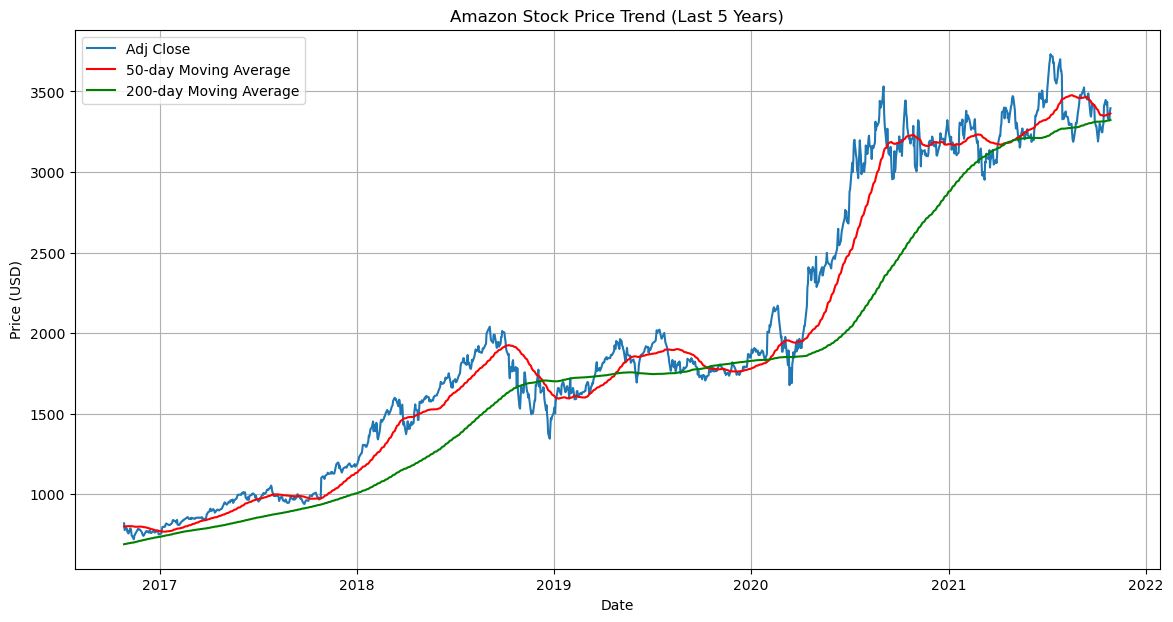

In [56]:
# Recovery Analysis (Dot-com bubble)
dotcom_start = '1999-12-01'
dotcom_end = '2005-12-31'
dotcom_period = df.loc[dotcom_start:dotcom_end]

# Top 5 Best and Worst Days
best_days = df['Daily Return'].nlargest(5)
worst_days = df['Daily Return'].nsmallest(5)

# Monthly Seasonality
df['Month'] = df.index.month
monthly_avg_return = df.groupby('Month')['Daily Return'].mean() * 100

# Recent Performance (Last 5 Years)
recent_df = df[df.index >= df.index.max() - pd.DateOffset(years=5)]
recent_return = (recent_df['Adj Close'][-1] / recent_df['Adj Close'][0] - 1) * 100
recent_cagr = ((recent_df['Adj Close'][-1] / recent_df['Adj Close'][0]) ** (1 / 5) - 1) * 100

# Visualization 4: Monthly Average Returns (Seasonality)
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_avg_return.index, y=monthly_avg_return.values, palette='viridis')
plt.title('Average Daily Return by Month (%)')
plt.xlabel('Month')
plt.ylabel('Average Daily Return (%)')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.savefig('amazon_seasonality.png')

# Visualization 5: Recent 5 Years Performance
plt.figure(figsize=(14, 7))
plt.plot(recent_df['Adj Close'], label='Adj Close')
plt.plot(recent_df['MA50'], label='50-day Moving Average', color='red')
plt.plot(recent_df['MA200'], label='200-day Moving Average', color='green')
plt.title('Amazon Stock Price Trend (Last 5 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('amazon_recent_trend.png')

print(f"Recent (Last 5 Years) Total Return: {recent_return:.2f}%")
print(f"Recent (Last 5 Years) CAGR: {recent_cagr:.2f}%")
print("\nTop 5 Best Days (Returns):")
print(best_days)
print("\nTop 5 Worst Days (Returns):")
print(worst_days)
print("\nMonthly Seasonality (Average Daily Return %):")
print(monthly_avg_return)

* Insights

* Long-term growth trend clearly show that stock clearly is in uptrend and after 2016 the growth is very fast almost exponential

* Bull and bear periods:There is no growths or very low uptrend during 2000 to 2008 after 2008 market is in uptrend 

* Market corrections: in 2017 to 2018 the market corrected

In [17]:
df['Daily Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily Return'].rolling(30).std()

In [18]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily Return,Volatility
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000,NaN,NaN
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000,-0.117021,NaN
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800,-0.012049,NaN
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200,-0.042683,NaN
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200,-0.127389,NaN
...,...,...,...,...,...,...,...,...,...
6150,2021-10-21,3414.250000,3440.280029,3403.000000,3435.010010,3435.010010,1881400,0.005842,0.013144
6151,2021-10-22,3421.000000,3429.840088,3331.300049,3335.550049,3335.550049,3133800,-0.028955,0.014130
6152,2021-10-25,3335.000000,3347.800049,3297.699951,3320.370117,3320.370117,2226000,-0.004551,0.014138
6153,2021-10-26,3349.510010,3416.120117,3343.979980,3376.070068,3376.070068,2693700,0.016775,0.014514


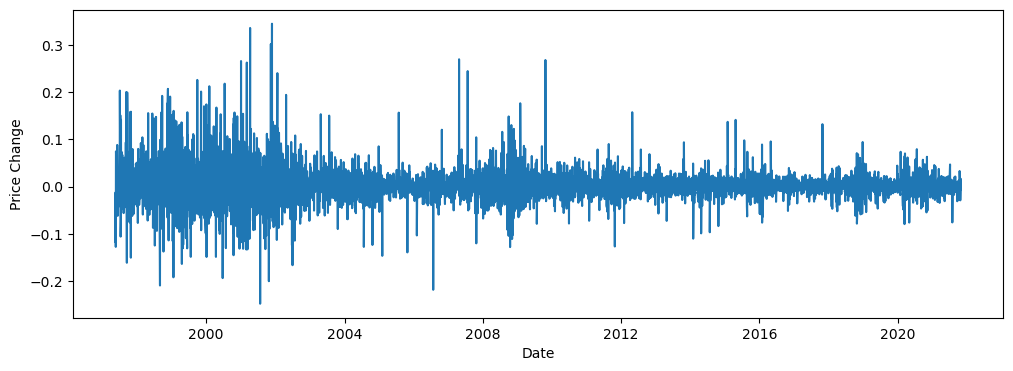

In [32]:
plt.figure(figsize = (12,4))
plt.plot(df['Date'], df['Daily Return'])
plt.xlabel('Date')
plt.ylabel('Price Change')
plt.show()

In [33]:
#The annual return on stock
df['Year'] = df['Date'].dt.year
annual_return = df.groupby('Year')['Close'].apply(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100)
print(annual_return)

Year
1997    156.383005
1998    979.832032
1999     28.684628
2000    -82.587413
2001    -22.018018
2002     72.354005
2003    168.880935
2004    -14.662814
2005      5.907462
2006    -17.066000
2007    139.379836
2008    -46.722079
2009    147.461371
2010     34.428684
2011     -6.036258
2012     40.127351
2013     54.984265
2014    -22.016734
2015    119.074951
2016     17.720844
2017     55.170034
2018     26.321054
2019     20.057432
2020     71.597089
2021      6.576228
Name: Close, dtype: float64


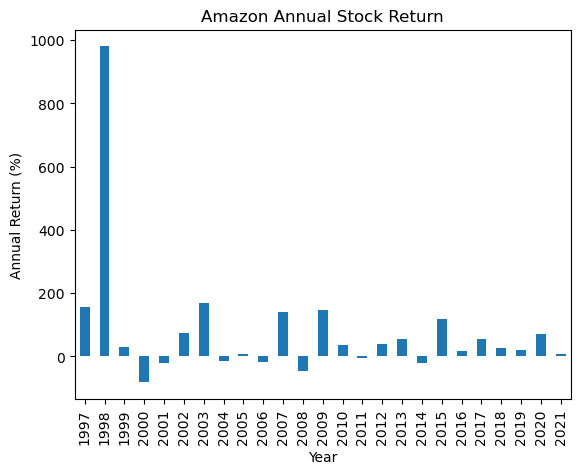

In [34]:
annual_return.plot(kind='bar')
plt.ylabel("Annual Return (%)")
plt.title("Amazon Annual Stock Return")
plt.show()

• The annual return analysis shows significant fluctuations in Amazon's stock performance across years.

• Positive annual returns indicate periods of strong market growth, while negative returns correspond to market corrections or macroeconomic pressures.

• Long-term analysis suggests that Amazon stock demonstrates strong growth potential despite short-term volatility.

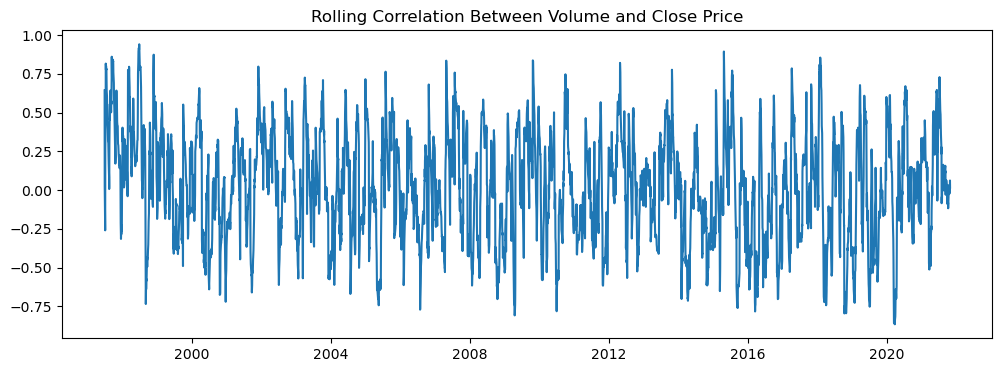

In [36]:
df['Rolling Corr'] = df['Volume'].rolling(30).corr(df['Close'])
plt.figure(figsize = (12,4))
plt.plot(df['Date'], df['Rolling Corr'])
plt.title("Rolling Correlation Between Volume and Close Price")
plt.show()

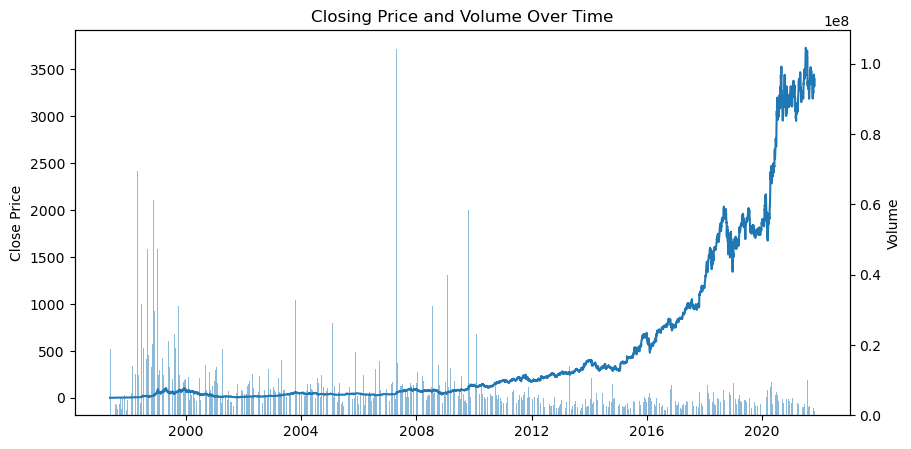

In [24]:
# We want to see the volume has an impact of closing price
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df['Date'], df['Close'], label='Close Price')
ax1.set_ylabel("Close Price")

ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Volume'], alpha=0.5, label='Volume')
ax2.set_ylabel("Volume")

plt.title("Closing Price and Volume Over Time")
plt.show()

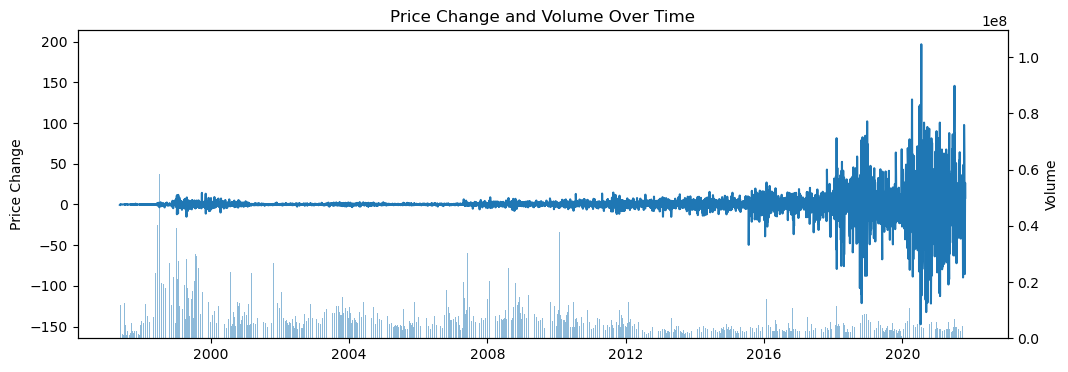

In [27]:
#Volume usually impacts price movement, not just price level.
df['Price Change'] = df['Close'] - df['Open']
fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(df['Date'], df['Price Change'], label='Price Change')
ax1.set_ylabel("Price Change")

ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Volume'], alpha=0.5, label='Volume')
ax2.set_ylabel("Volume")

plt.title("Price Change and Volume Over Time")
plt.show()

<AxesSubplot:>

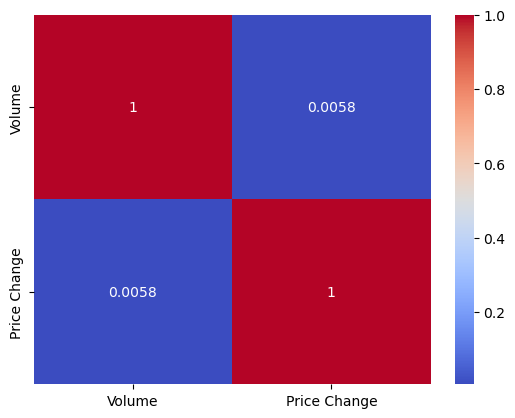

In [30]:
sns.heatmap(df[['Volume','Price Change']].corr(), annot = True, cmap='coolwarm')

<AxesSubplot:>

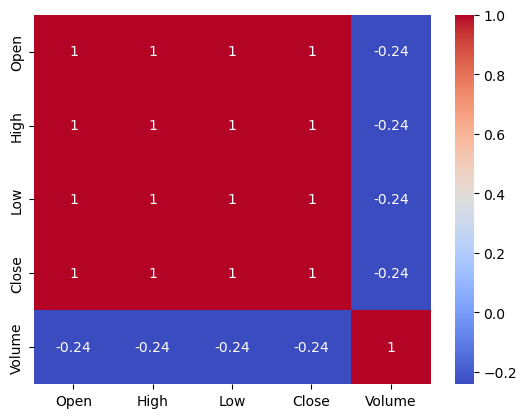

In [25]:
corr = df[['Open','High','Low','Close','Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')